# 000978 stage 1 — rate-matrix inspection

Load a binned rate matrix written by `src/000978/01_extraction.py` and check the
**binned** representation (notebook `00` checks raw spikes). Single-day W-track
learning: 17 epochs alternating sleep / run, with run epochs carrying a
`run_session` index 1..8 (per file). CA1 and PFC are kept separate.

Checks:
1. Contents / metadata; epoch table with kind + run_session
2. Rate-matrix heatmap (units × time), run epochs shaded
3. Per-unit rate & sparsity, run vs. sleep
4. Behavior aligned to bins: W-track run sessions vs. a sleep epoch
5. Cross-session neural drift — a preview of the learning-trajectory analysis

**ZT2 note:** ZT2's day is split across two files (`ZT2_obj-*`), each with 4 run
sessions; pick one to inspect. Other animals have all 8 in one file.


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000978")
BIN_MS = int(BIN_SIZE_S * 1000)
plt.rcParams["figure.dpi"] = 100
KIND_SHADE = {"run": "green"}
REGION_COLOR = {"CA1": "tab:blue", "PFC": "tab:red"}

## Pick a rate matrix

In [2]:
available = sorted(DATA_PROCESSED.glob(f"rates_*_{BIN_MS}ms.npz"))
for i, f in enumerate(available): print(i, f.name)
assert available, "no matrices — run: pixi run python src/000978/01_extraction.py"

RATE_FILE = available[0]   # change index for another session / region
d = np.load(RATE_FILE, allow_pickle=False)
session, subject, region = str(d["session_key"]), str(d["subject"]), str(d["region"])
dt = float(d["bin_size_s"])
print(f"\nloaded {RATE_FILE.name}: session={session} subject={subject} region={region} bin={dt*1000:.0f}ms")

0 rates_ER1_CA1_1000ms.npz
1 rates_ER1_PFC_1000ms.npz
2 rates_JS14_CA1_1000ms.npz
3 rates_JS14_PFC_1000ms.npz
4 rates_JS15_CA1_1000ms.npz
5 rates_JS15_PFC_1000ms.npz
6 rates_JS17_CA1_1000ms.npz
7 rates_JS17_PFC_1000ms.npz
8 rates_JS21_CA1_1000ms.npz
9 rates_JS21_PFC_1000ms.npz
10 rates_JS34_CA1_1000ms.npz
11 rates_JS34_PFC_1000ms.npz
12 rates_KL8_CA1_1000ms.npz
13 rates_KL8_PFC_1000ms.npz
14 rates_ZT2_obj-1dss6zi_CA1_1000ms.npz
15 rates_ZT2_obj-1dss6zi_PFC_1000ms.npz
16 rates_ZT2_obj-u40err_CA1_1000ms.npz
17 rates_ZT2_obj-u40err_PFC_1000ms.npz

loaded rates_ER1_CA1_1000ms.npz: session=ER1 subject=JDS-SingleDay-ER1 region=CA1 bin=1000ms


## 1. Contents and epoch structure

In [3]:
rates, epoch, kind, run_session = d["rates"], d["epoch"], d["kind"], d["run_session"]
T, n_units = rates.shape
print("keys      :", list(d.keys()))
print("rates     :", rates.shape, rates.dtype, "(sqrt spike counts / bin)")
print("time span :", f"{d['time'][0]:.0f}-{d['time'][-1]:.0f} s "
      f"({(d['time'][-1]-d['time'][0])/3600:.1f} h)")

rows = []
for e in np.unique(epoch):
    m = epoch == e
    rows.append(dict(epoch=int(e), kind=str(kind[m][0]),
                     run_session=int(run_session[m][0]), n_bins=int(m.sum())))
pd.DataFrame(rows)

keys      : ['rates', 'time', 'position', 'velocity', 'epoch', 'kind', 'run_session', 'unit_ids', 'bin_size_s', 'subject', 'session_key', 'region', 'source']
rates     : (19300, 82) float32 (sqrt spike counts / bin)
time span : 366-21747 s (5.9 h)


,epoch,kind,run_session,n_bins
0,0,sleep,-1,902
1,1,run,1,947
2,2,sleep,-1,950
3,3,run,2,970
4,4,sleep,-1,901
5,5,run,3,948
6,6,sleep,-1,1225
7,7,run,4,968
8,8,sleep,-1,1785
9,9,run,5,969


## 2. Rate-matrix heatmap
Units × time; green bands = run (W-track) epochs, gaps = sleep.

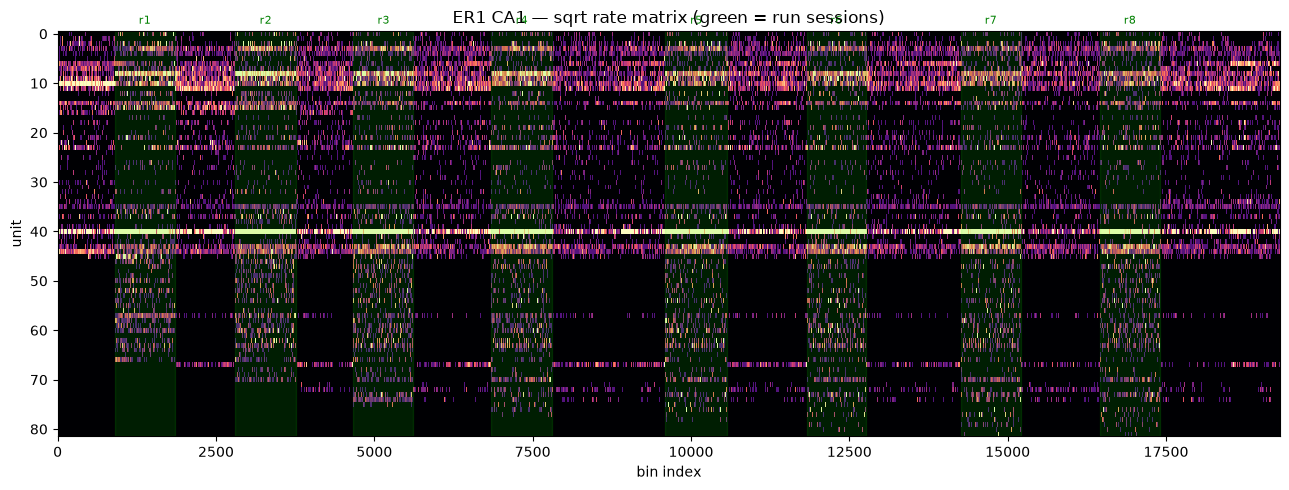

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(rates.T, aspect="auto", interpolation="nearest", cmap="magma",
          vmax=np.percentile(rates, 99))
# shade run epochs by bin index
bounds = np.flatnonzero(np.diff(epoch)) + 1
edges = np.concatenate([[0], bounds, [T]])
for k in range(len(edges) - 1):
    lo, hi = edges[k], edges[k + 1]
    if kind[lo] == "run":
        ax.axvspan(lo, hi, color="lime", alpha=0.12)
        ax.text((lo + hi) / 2, -1.5, f"r{int(run_session[lo])}", ha="center",
                va="bottom", fontsize=8, color="green")
ax.set_xlabel("bin index"); ax.set_ylabel("unit")
ax.set_title(f"{session} {region} — sqrt rate matrix (green = run sessions)")
plt.tight_layout()

## 3. Per-unit rate & sparsity, run vs. sleep

median rate run 0.49 Hz vs sleep 0.13 Hz


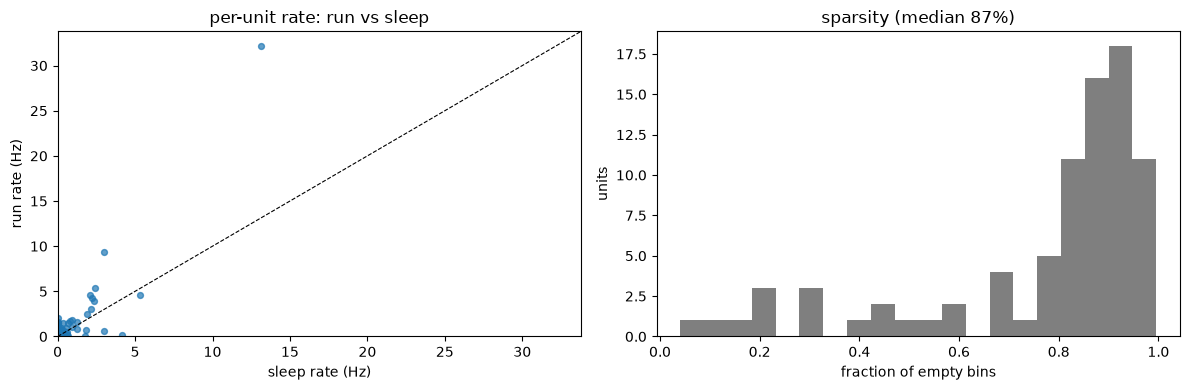

In [5]:
counts = rates.astype(np.float64) ** 2
run_m, sleep_m = kind == "run", kind == "sleep"
run_hz = counts[run_m].sum(0) / (run_m.sum() * dt)
sleep_hz = counts[sleep_m].sum(0) / (sleep_m.sum() * dt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(sleep_hz, run_hz, s=18, alpha=0.7, color=REGION_COLOR.get(region))
lim = [0, max(run_hz.max(), sleep_hz.max()) * 1.05]
axes[0].plot(lim, lim, "k--", lw=0.8); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("sleep rate (Hz)"); axes[0].set_ylabel("run rate (Hz)")
axes[0].set_title("per-unit rate: run vs sleep")
sparsity = (counts == 0).mean(0)
axes[1].hist(sparsity, bins=20, color="tab:gray")
axes[1].set_xlabel("fraction of empty bins"); axes[1].set_ylabel("units")
axes[1].set_title(f"sparsity (median {np.median(sparsity):.0%})")
plt.tight_layout()
print(f"median rate run {np.median(run_hz):.2f} Hz vs sleep {np.median(sleep_hz):.2f} Hz")

## 4. Behavior aligned to bins
Each run session's W-track trajectory, plus one sleep epoch (rest box).

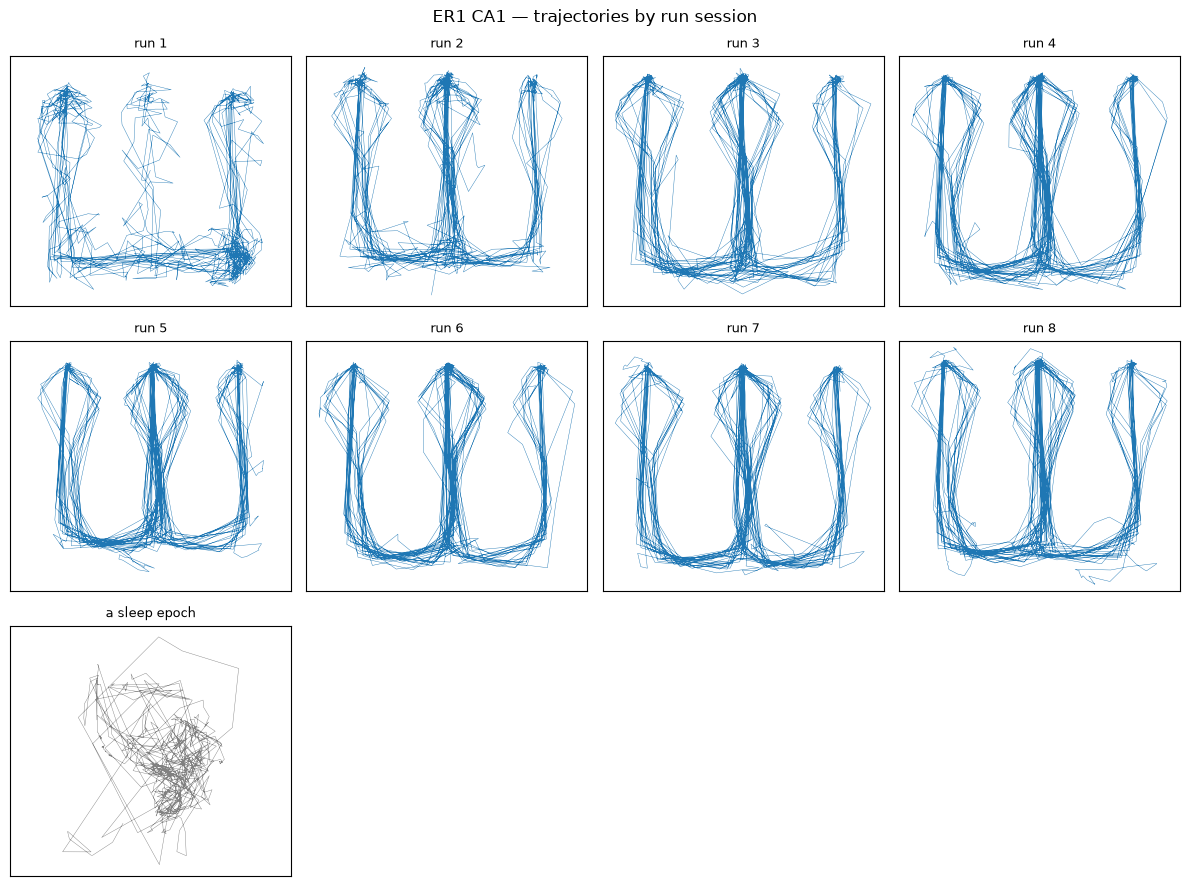

In [6]:
pos = d["position"]
run_ids = sorted(np.unique(run_session[run_session > 0]))
ncol = 4; nrow = int(np.ceil((len(run_ids) + 1) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow)); axes = axes.ravel()
for k, s in enumerate(run_ids):
    m = run_session == s
    axes[k].plot(pos[m, 0], pos[m, 1], lw=0.3)
    axes[k].set_title(f"run {s}", fontsize=9)
    axes[k].set_aspect("equal", adjustable="datalim"); axes[k].set_xticks([]); axes[k].set_yticks([])
sm = (kind == "sleep")
first_sleep_ep = epoch[sm][0]
m = epoch == first_sleep_ep
axes[len(run_ids)].plot(pos[m, 0], pos[m, 1], lw=0.3, color="gray")
axes[len(run_ids)].set_title("a sleep epoch", fontsize=9)
axes[len(run_ids)].set_aspect("equal", adjustable="datalim"); axes[len(run_ids)].set_xticks([]); axes[len(run_ids)].set_yticks([])
for j in range(len(run_ids) + 1, len(axes)): axes[j].axis("off")
fig.suptitle(f"{session} {region} — trajectories by run session")
plt.tight_layout()

## 5. Cross-session neural drift

Mean population activity per run session, and the correlation between sessions'
mean population vectors. Systematic drift across sessions is the neural signature
the stage-6b learning-trajectory analysis will quantify.

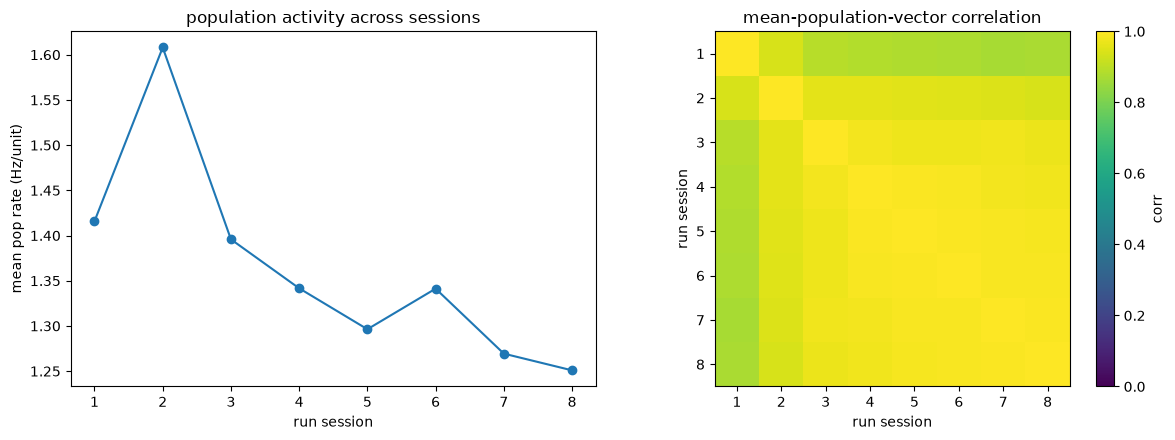

In [7]:
M = np.vstack([rates[run_session == s].mean(0) for s in run_ids])   # (n_sessions, n_units)
pop_rate = np.array([(counts[run_session == s].sum() /
                      ((run_session == s).sum() * n_units * dt)) for s in run_ids])
C = np.corrcoef(M)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(run_ids, pop_rate, "o-")
axes[0].set_xlabel("run session"); axes[0].set_ylabel("mean pop rate (Hz/unit)")
axes[0].set_title("population activity across sessions")
im = axes[1].imshow(C, vmin=0, vmax=1, cmap="viridis")
axes[1].set_xticks(range(len(run_ids))); axes[1].set_xticklabels(run_ids)
axes[1].set_yticks(range(len(run_ids))); axes[1].set_yticklabels(run_ids)
axes[1].set_xlabel("run session"); axes[1].set_ylabel("run session")
axes[1].set_title("mean-population-vector correlation")
fig.colorbar(im, ax=axes[1], label="corr")
plt.tight_layout()

---
**Next:** stage 2 baselines (PCA/GPFA/dPCA) and stage 3 CEBRA on these 000978
matrices, then the 000978-specific 6b (session-sequence alignment) and 6c
(sleep-epoch replay projection). ZT2's two files need their run sessions stitched
into a global 1–8 order first.